In [5]:
import numpy as np
import matplotlib.pyplot as plt
# Import
import camb


In [55]:
# Maximum multipole of the spectra, which is set by the maps resolution
lmax = 5000

# Set up a new set of parameters for CAMB
# The defaults give one massive neutrino and helium set using BBN consistency
cosmo_params = dict(
    H0=67.5, # Hubble constant today, in km/s/Mpc. Sets the present expansion rate.
    ombh2=0.022, # Physical baryon density, controls the baryon content: protons, nuclei, electrons.
    omch2=0.122, # Physical cold dark matter density, controls the CDM abundance.
    mnu=0.6, # Sum of neutrino masses, in eV.
    omk=0.0, # Curvature density, 0.0 means a spatially flat Universe.
    tau=0.06, # Optical depth to reionization.
    As=2.0e-9, # Amplitude of the primordial scalar power spectrum, defined at a pivot scale. Sets the overall amplitude of initial perturbations.
    ns=0.965, # Scalar spectral index. Controls the tilt of the primordial scalar spectrum; ns < 1 means slightly more power on large scales than small scales.
    halofit_version="mead", # Choice of nonlinear matter power spectrum correction. "mead" refers to the Mead/HMCode-style nonlinear prescription.
    lmax=lmax,
)
pars = camb.set_params(**cosmo_params, WantTransfer=True)
# print(pars)
pars.set_for_lmax(lmax, lens_potential_accuracy=2)

# Compute results for these parameters
results = camb.get_results(pars)
cls = results.get_total_cls(lmax=lmax, CMB_unit="muK")

# Matter power Spectrum
# pk_interpolator = results.get_matter_power_interpolator(
#     var1='delta_tot', var2='delta_tot', hubble_units=True, k_hunit=True
# )
# pk_val = pk_interpolator.P(z=0, k=0.1)  # P(k) at z=0, k=0.1 h/Mpc

results.calc_power_spectra()

results.calc_transfers(pars)
mp_spec = results.get_matter_power_spectrum()
# save the matter power spectrum as a dat file

np.savetxt("CAMB_massiveNu.dat", np.column_stack([mp_spec[0], mp_spec[2][0]]))

# print(mp_spec)
# CAMB returns columns TT, EE, BB, TE. Store them with ell as the first column.
# This file will be used by later notebooks.
ell = np.arange(lmax + 1)
np.savetxt("CAMB_fiducial_cosmo_scalCls_massiveNu.dat", np.column_stack([ell, cls]))

print("Saved CAMB_fiducial_cosmo_scalCls.dat with columns ell, TT, EE, BB, TE.")

Saved CAMB_fiducial_cosmo_scalCls.dat with columns ell, TT, EE, BB, TE.


[]

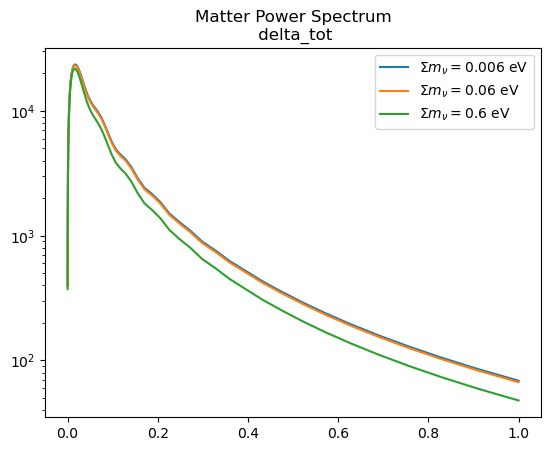

In [58]:
kz, Pk = np.loadtxt("CAMB_fiducial.dat", usecols=(0, 1), unpack=True)
kz_mNu, Pk_mNu = np.loadtxt("CAMB_massiveNu.dat", usecols=(0, 1), unpack=True)
kz_lNu, Pk_lNu = np.loadtxt("CAMB_lightNu.dat", usecols=(0, 1), unpack=True)


plt.plot(kz_lNu, Pk_lNu, label=r"$\Sigma m_{\nu}=0.006$ eV")
plt.plot(kz, Pk, label=r"$\Sigma m_{\nu}=0.06$ eV")
plt.plot(kz_mNu, Pk_mNu, label=r"$\Sigma m_{\nu}=0.6$ eV")
plt.legend()
plt.title("Matter Power Spectrum\n delta_tot")
plt.semilogy()

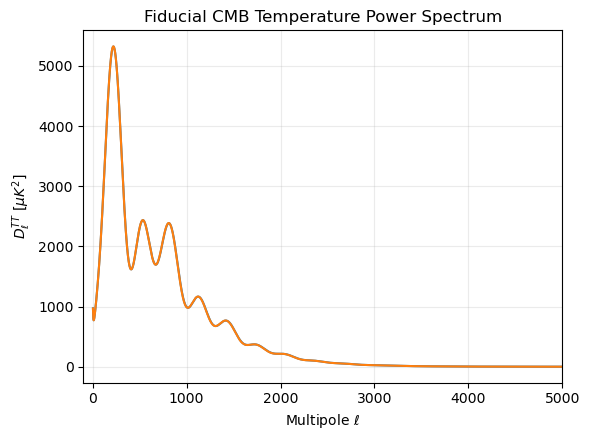

In [10]:
# ============================================================
# 1.2  Read and plot the temperature spectrum
# ============================================================

ell, DlTT = np.loadtxt("CAMB_fiducial_cosmo_scalCls.dat", usecols=(0, 1), unpack=True)
ell_mNu, DlTT_mNu = np.loadtxt("CAMB_fiducial_cosmo_scalCls_massiveNu.dat", usecols=(0, 1), unpack=True)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ell[2:], DlTT[2:], color="C0")
ax.plot(ell_mNu[2:], DlTT_mNu[2:], color="C1")

ax.set_xlim(-100, 5000)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}$ [$\mu K^2$]")
ax.set_title("Fiducial CMB Temperature Power Spectrum")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
